In [25]:
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")


from analytic.formulas import *

In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
import os
import json
import pandas as pd
import string
# Set the folder containing the JSON files
folder_path = "/home/fabianhelmberger/gitrepos/clonscal/results/gaussian_sim_data/"

# List all JSON files in the folder
json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

# Initialize a list to store data
data_list = []

histograms_p = {}
histograms_u = {}

# Loop through the JSON files and load them into a DataFrame
for idx, file in enumerate(json_files):
    file_path = os.path.join(folder_path, file)
       

    with open(file_path, "r") as f:
        data = json.load(f)

    # Flatten the structure
    flattened_data = {
        "steps": data["params"]["steps"],
        "trajs": data["params"]["trajs"],
        "dt": data["params"]["dt"],
        "sigma_abs": data["params"]["sigma_abs"],
        "sigma_phase": data["params"]["sigma_phase"],
        "lambda_abs": data["params"]["lambda_abs"],
        "mass_modification": data["params"]["mass_modification"],
        "pullback": data["params"]["pullback"],
        "bins_u": data["params"]["bins_u"],
        "bins_p": data["params"]["bins_p"],
        "p_min_real": data["params"]["p_min_real"],
        "p_max_real": data["params"]["p_max_real"],
        "p_min_imag": data["params"]["p_min_imag"],
        "p_max_imag": data["params"]["p_max_imag"],
        "u_min": data["params"]["u_min"],
        "u_max": data["params"]["u_max"],
    }

    # Add dse moment values
    for moment in ["dse_1_moment", "dse_2_moment", "dse_3_moment","dse_4_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = data[moment][key]

    for moment in ["1_moment", "2_moment", "3_moment","4_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = float(data[moment][key])
    flattened_data["idx"] = idx
    data_list.append(flattened_data)

    with open(file_path[:-5]+"_hist_p.npy", 'rb') as f:
        hist_p = np.load(f)
        histograms_p[idx] = hist_p

    with open(file_path[:-5]+"_hist_u.npy", 'rb') as f:
        hist_u = np.load(f)
        histograms_u[idx] = hist_u
    


# Create the DataFrame
df = pd.DataFrame(data_list)
df

,steps,trajs,dt,sigma_abs,sigma_phase,lambda_abs,mass_modification,pullback,bins_u,bins_p,...,2_moment_mean_real,2_moment_mean_imag,2_moment_sem,3_moment_mean_real,3_moment_mean_imag,3_moment_sem,4_moment_mean_real,4_moment_mean_imag,4_moment_sem,idx
0,10000,500000,0.001,4.123106,1.815775,2,2.5,200,10000,1000,...,0.397126,-0.000250,0.000265,-0.000740,-0.000001,0.000459,0.474617,0.001644,0.000735,0
1,10000,500000,0.001,4.123106,1.815775,2,2.5,200,10000,1000,...,0.397126,-0.000250,0.000265,-0.000740,-0.000001,0.000459,0.474617,0.001644,0.000735,1
2,10000,500000,0.001,4.123106,1.815775,2,2.5,100,10000,1000,...,0.394606,-0.000518,0.000265,-0.000711,-0.000002,0.000458,0.470549,0.003241,0.000735,2
3,10000,500000,0.001,4.123106,1.815775,2,5.0,200,10000,1000,...,0.197901,-0.001523,0.000131,0.000037,-0.000005,0.000161,0.116530,0.000157,0.000186,3
4,10000,500000,0.001,4.123106,1.815775,2,5.0,100,10000,1000,...,0.196095,-0.004436,0.000131,0.000114,-0.000029,0.000162,0.114808,-0.003280,0.000195,4
5,1000,500000,0.010,4.123106,1.815775,2,5.0,50,10000,1000,...,0.199054,-0.011676,0.000141,-0.000159,0.000008,0.000181,0.120528,-0.014424,0.000229,5
6,1000,500000,0.010,4.123106,1.815775,2,2.5,50,10000,1000,...,0.394500,-0.000981,0.000266,0.000055,-0.000041,0.000464,0.473593,0.006305,0.000752,6
7,1000,500000,0.010,4.123106,1.815775,2,10.0,200,10000,1000,...,0.108322,-0.005508,0.000084,-0.000022,0.000056,0.000091,0.037955,-0.008483,0.000110,7
8,1000,500000,0.010,4.123106,1.815775,2,10.0,100,10000,1000,...,0.112736,-0.010627,0.000096,0.000103,-0.000009,0.000114,0.043414,-0.017692,0.000151,8


In [28]:
# solve_floweq
from scipy.integrate import solve_ivp

def stop_event(t, z, *args, **kwargs):
    x, y = z
    return max(x, y) - 10  # Triggers when either x or y reaches 10

stop_event.terminal = True

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    mass_modification = kwargs.get("mass_modification", 5)

    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    flow_times = []
    
    directions_num = 4
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, mass_modification), t_eval=t_eval, method="BDF", events=stop_event)
        sol.append(solution.y[0] + 1j * solution.y[1])
        flow_times.append(solution.t)
    return sol, flow_times


In [29]:
# drift func

# gaussian mod
@np.vectorize
def drift_func(z, sigma, lamb, pullback, mass_modification):
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        return drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        return drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)

def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

In [30]:
# root finder

def F_real(z_real, sigma, lamb, pullback, mass_modification):
    z = z_real[0] + 1j * z_real[1]
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        out = drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        out =  drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)
    return np.array([out.real, out.imag])


from scipy.optimize import root as root_scipy

def find_roots(guess, sigma, lamb, pullback, mass_modification):
    sol = root_scipy(F_real, guess, method='hybr', args=(sigma, lamb, pullback, mass_modification))
    if sol.success:
        root_found = sol.x[0] + 1j * sol.x[1]
        return root_found
    return 0

In [31]:
# action
@np.vectorize
def action_mod(z, sigma, lamb, pullback, mass_modification):
    if np.real(np.log10(pullback)+sigma/2*z**2 + lamb/4*z**4 -mass_modification/2*z**2) > 100:
        return sigma/2*z**2 + lamb/4*z**4-np.log(pullback)*(sigma/2*z**2 + lamb/4*z**4 - mass_modification/2*z**2)  
    return sigma/2*z**2 + lamb/4*z**4-np.log(1+pullback*np.exp(sigma/2*z**2 + lamb/4*z**4 - mass_modification/2*z**2))

@np.vectorize
def action_unmod(z, sigma, lamb):
    return sigma/2*z**2+lamb/4*z**4

@np.vectorize
def drift_unmod(z, sigma, lamb):
    return sigma*z+lamb*z**3

/tmp/ipykernel_84677/1465966467.py:13: RuntimeWarning: invalid value encountered in cdouble_scalars
  out =  drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)


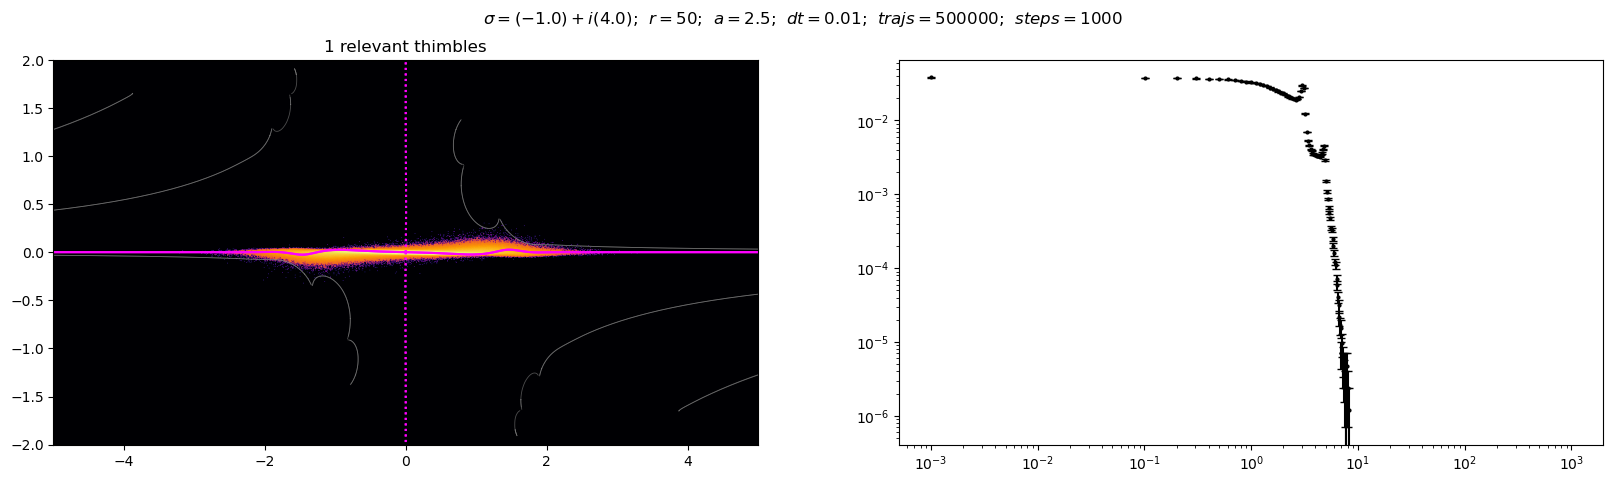

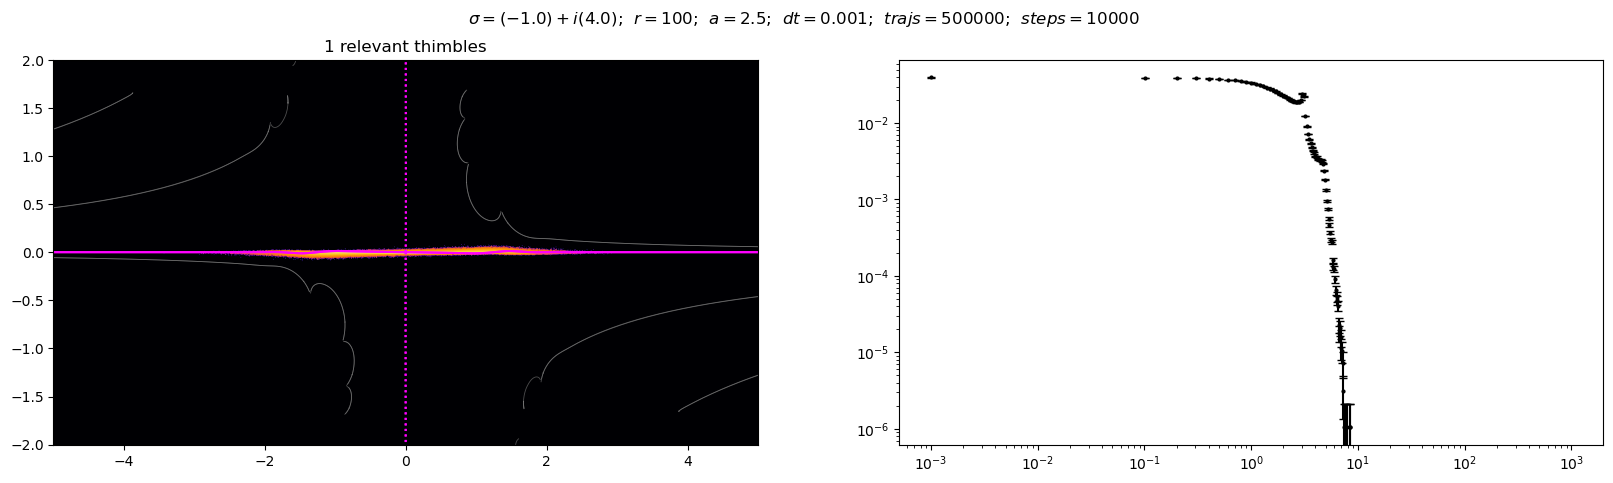

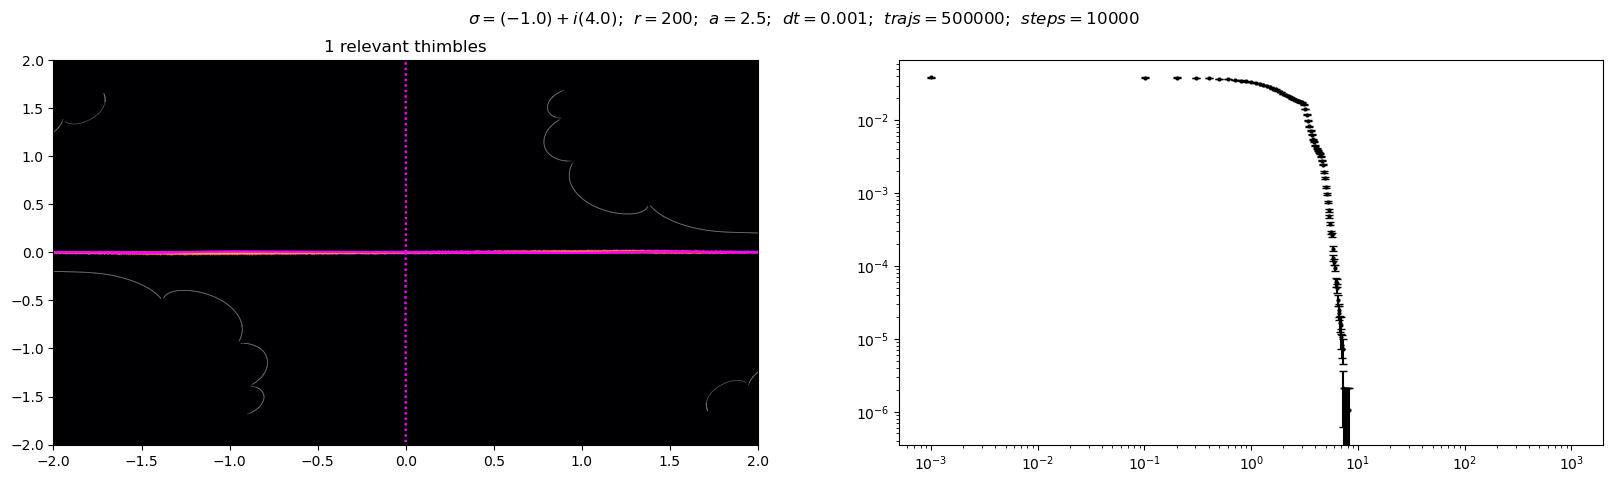

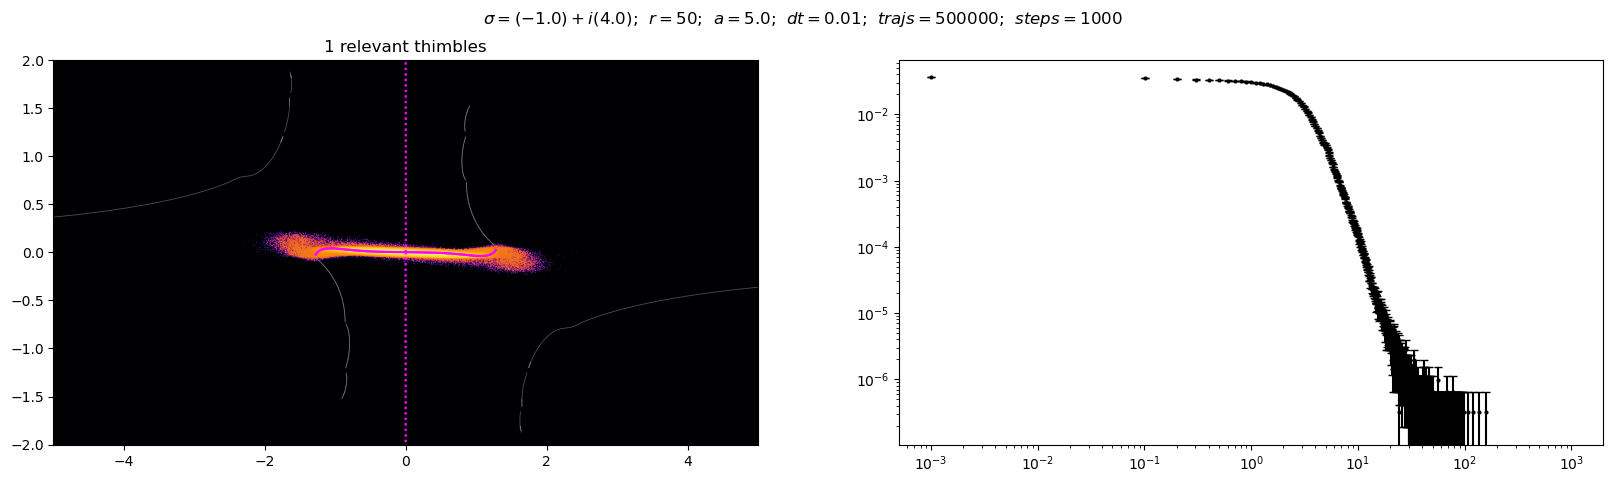

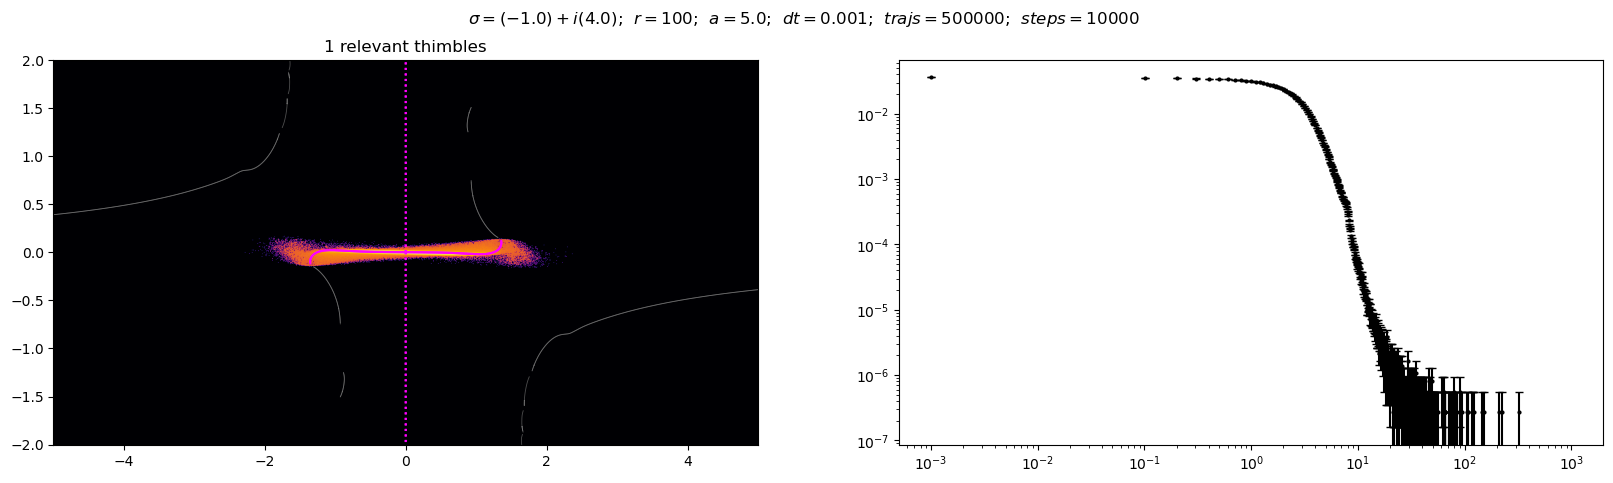

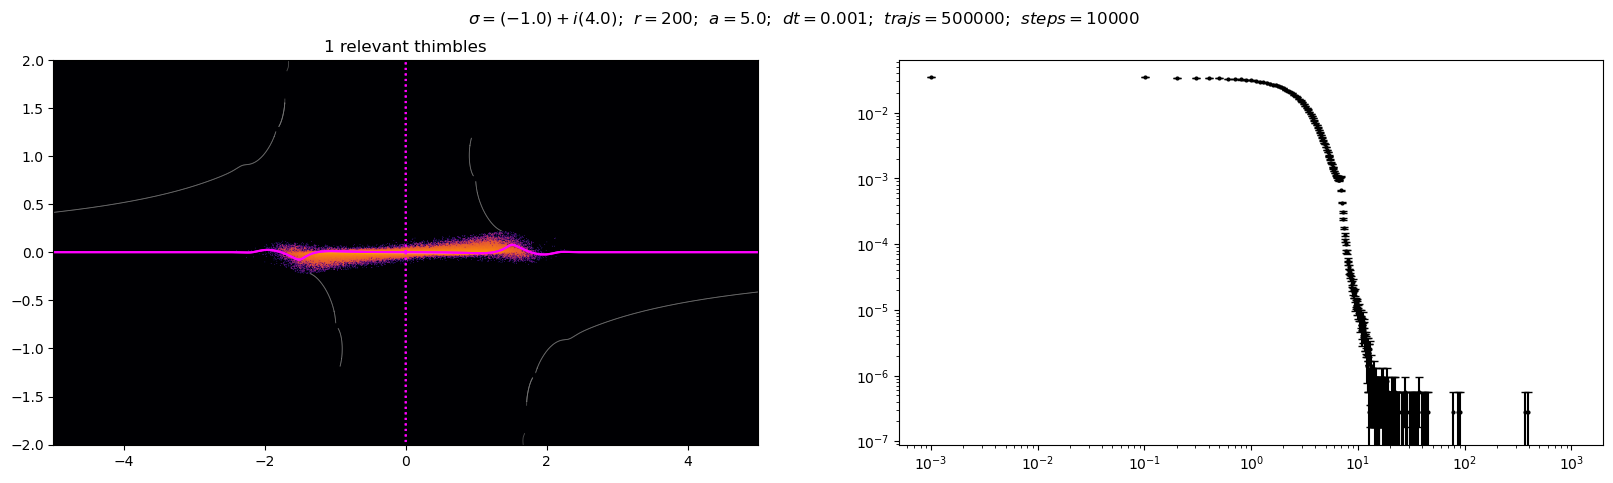

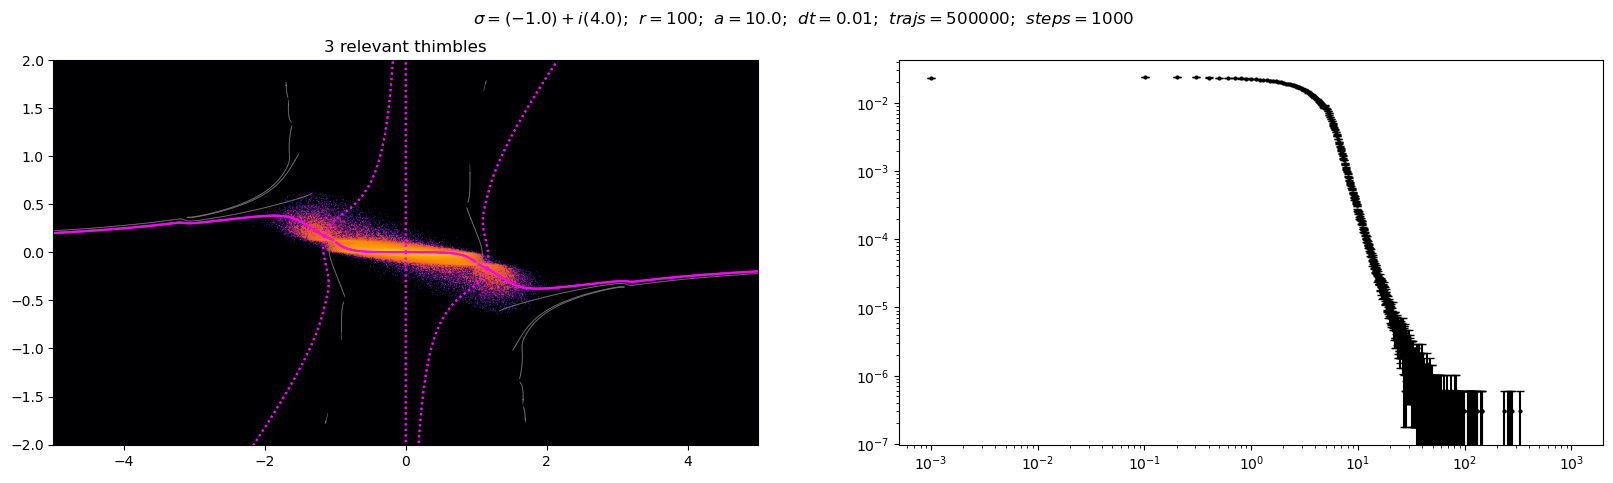

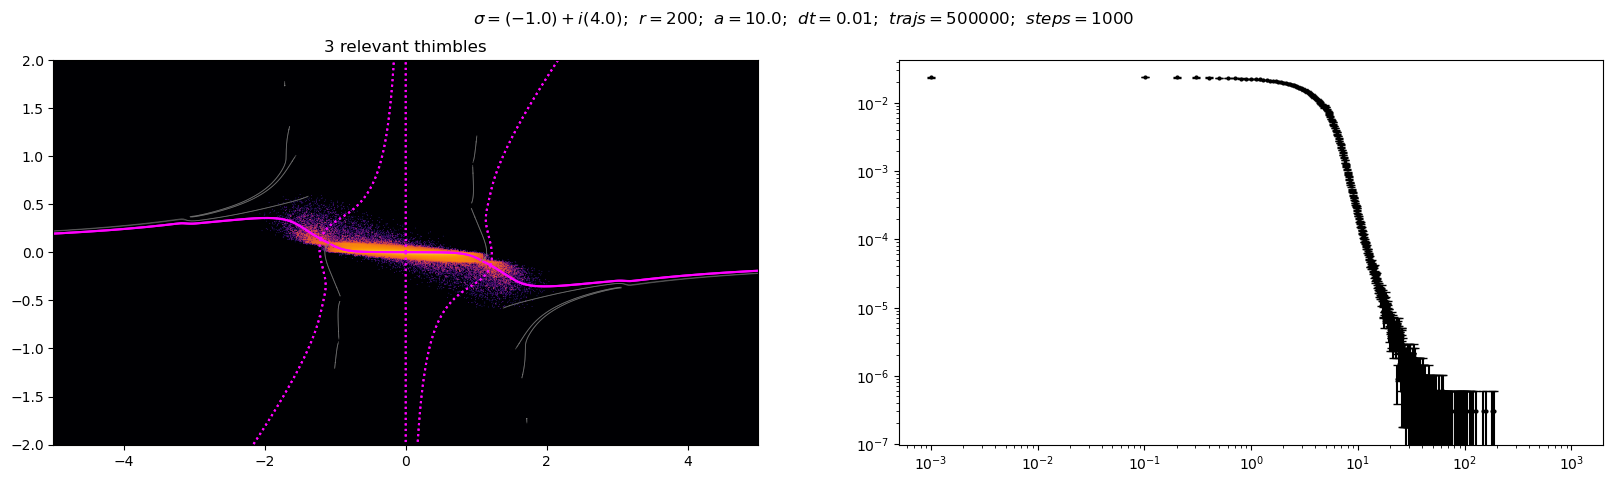

In [32]:
import matplotlib.cm as cm

for (sigma_abs, sigma_phase,lambda_abs, mass_modification, pullback), group in df.groupby(["sigma_abs", "sigma_phase", "lambda_abs", "mass_modification", "pullback"]):
    
    sigma = sigma_abs*np.exp(1j*sigma_phase)
    idx = group["idx"].unique()[0]
    hist_p = histograms_p[idx]
    hist_u = histograms_u[idx]
    p_min_real = group["p_min_real"].unique()[0]
    p_max_real = group["p_max_real"].unique()[0]
    p_min_imag = group["p_min_imag"].unique()[0]
    p_max_imag = group["p_max_imag"].unique()[0]
    dt = group["dt"].unique()[0]
    trajs = group["trajs"].unique()[0]
    steps = group["steps"].unique()[0]
    

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle(rf"$\sigma = ({{{np.real(sigma)}}}) + i({{{np.imag(sigma)}}})$;  $r = {{{pullback}}}$;  $a = {{{mass_modification}}}$;  $dt = {{{dt}}}$;  $trajs = {{{trajs}}}$;  $steps = {{{steps}}}$")
    hist_u_norm = hist_u / np.sum(hist_u)

    errors = np.sqrt(hist_u) / np.sum(hist_u)  # Normalize errors

    U_min, U_max = 0.001, 1000.0
    U_bins = np.linspace(U_min, U_max, len(hist_u_norm))
    U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
    ax[1].errorbar(U_bins, hist_u_norm, yerr=errors, fmt='o', color='black', markersize=2, capsize=3)
    ax[1].set_yscale("log")
    ax[1].set_xscale("log")

    # Create the figure and axis
    ax[0].imshow(np.log10(hist_p.T+1e-6), origin='lower', aspect='auto', extent=[p_min_real, p_max_real, p_min_imag, p_max_imag], cmap='inferno')

    # Thimbles
    x_vals = np.linspace(-5, 5, 10)  # Real part of z
    y_vals = np.linspace(-5, 5, 10)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]
    roots = []
    for guess in initial_guesses:
        root_found = find_roots(guess,sigma = sigma, lamb=lambda_abs, pullback=pullback, mass_modification=mass_modification)
        if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
            roots.append(root_found)
    
    num_relevant = 0
    cols_idx = np.linspace(0, 1, len(roots))

    for roo, col in zip(roots,  cm.rainbow(cols_idx)):
        # print(f"drift zero: {roo}")
        solutions, flow_times = solve_floweq(flow_equation_unstable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                sigma = sigma, lamb=lambda_abs, pullback=pullback, mass_modification=mass_modification)
                
        relevant = False
        conc_sol = np.concatenate(solutions, axis = 0)
        if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True; num_relevant += 1

        for sol in solutions:
            if relevant:
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = ':')  # Set transparency for better visibility
            else: pass
                # ax[0].plot(sol.real, sol.imag, color = 'gray', ls = ':')  # Set transparency for better visibility

        # stable
        solutions, flow_times = solve_floweq(flow_equation_stable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                             sigma = sigma, lamb=lambda_abs, pullback=pullback, mass_modification=mass_modification)
        for sol, fl_time in zip(solutions, flow_times):
            # ax[1].set_title(len(solutions))
            if relevant:
                # print(f"minimal action: {np.min(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                # print(f"maximal action: {np.max(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = "solid")
                # ax[1].scatter(fl_time,(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification))), s=1, color = col)
            else:
                ax[0].plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        ax[0].set_title(f"{num_relevant} relevant thimbles")
        ax[0].set_xlim(p_min_real, p_max_real)
        ax[0].set_ylim(p_min_imag, p_max_imag)